# For prediction

predict housing prices based on various features. By adding a penalty term to the regression

In [1]:
# Necessary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# California Housing dataset:
dataset = fetch_california_housing(as_frame=True)
X = dataset.data
y = dataset.target

In [3]:
# split the dataset into training and testing sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [6]:
# StandardScaler class to scale the input data:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [7]:
# define the Lasso Regression model: (hyperparameter λ to 0.1.)
model = Lasso(alpha=0.1)

In [8]:
# fit the model to the training data:
model.fit(X_train, y_train)

Lasso(alpha=0.1)

In [9]:
# make predictions on the test data:
y_pred = model.predict(X_test)

In [10]:
# evaluate the performance of the model using the mean squared error:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.6900357507403247


In [ ]:
# Formula


# Feature Selection

Coeficientes Lasso:
age     -0.000000
sex   -155.359976
bmi    517.186795
bp     275.077235
s1     -52.539365
s2      -0.000000
s3    -210.157991
s4       0.000000
s5     483.912648
s6      33.673965
dtype: float64


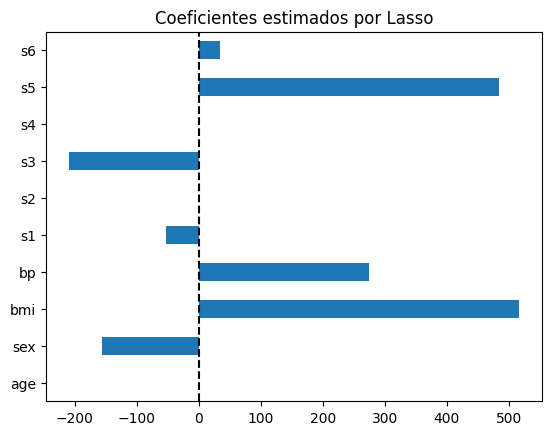

In [11]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso
import pandas as pd
import matplotlib.pyplot as plt

# Diabetes:
X, y = load_diabetes(return_X_y=True)
feature_names = load_diabetes().feature_names

# Adjust Lasso model with moderate penalty
lasso = Lasso(alpha=0.1)
lasso.fit(X, y)

# Show coefficients
coef = pd.Series(lasso.coef_, index=feature_names)
print("Coeficientes Lasso:")
print(coef)

# Visual
coef.plot(kind='barh', title='Coeficientes estimados por Lasso')
plt.axvline(0, color='black', linestyle='--')
plt.show()


Lasso has "forced" some variables to disappear and reduced the impact of others. This is useful to avoid complex and over-tuned models.

# Avoid overfitting

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Add noise and artificial correlation
X_noisy = X + np.random.normal(0, 0.1, X.shape)
X_train, X_test, y_train, y_test = train_test_split(X_noisy, y, test_size=0.3, random_state=42)

# Normal linear regression
lr = LinearRegression().fit(X_train, y_train)
mse_lr = mean_squared_error(y_test, lr.predict(X_test))

# Lasso
lasso = Lasso(alpha=0.2).fit(X_train, y_train)
mse_lasso = mean_squared_error(y_test, lasso.predict(X_test))

print(f"MSE Regresión Lineal: {mse_lr:.2f}")
print(f"MSE Lasso: {mse_lasso:.2f}")


MSE Regresión Lineal: 4751.05
MSE Lasso: 4635.03


This suggests that Lasso generalizes better to the test set by penalizing the coefficients and preventing the model from learning too much from noise (i.e., avoiding overfitting).

# Regularization for simple and stable models

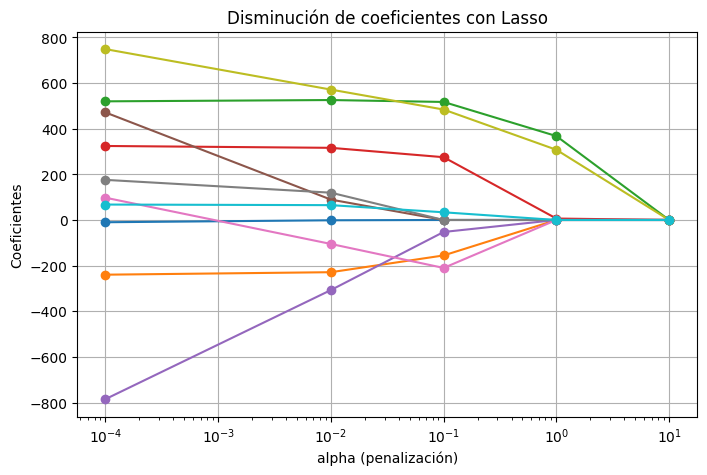

In [31]:
alphas = [0.0001, 0.01, 0.1, 1, 10]
coefs = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X, y)
    coefs.append(lasso.coef_)

# Visualizar la magnitud de los coeficientes según alpha
plt.figure(figsize=(8, 5))
for coef in zip(*coefs):
    plt.plot(alphas, coef, marker='o')
plt.xscale('log')
plt.xlabel('alpha (penalización)')
plt.ylabel('Coeficientes')
plt.title('Disminución de coeficientes con Lasso')
plt.grid(True)
plt.show()


Low alpha: greater adjustment but risk of overadjustment.

High alpha: lower variance, better generalization, but possible loss of information if important variables are eliminated.




---

illustrates Lasso's regularization power: you can choose the alpha value that best balances simplicity vs. precision.

---



# THEN...
there are algorithms and automatic strategies to Choose the optimal value of
𝜆

In [32]:
# 1. Cross-validation (LassoCV)
# The model tests multiple alpha values and selects the one that gives the least cross-validation error.
from sklearn.linear_model import LassoCV

# Lasso con validación cruzada (por default usa 5 folds)
lasso_cv = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10], cv=5)
lasso_cv.fit(X, y)

print("Mejor alpha encontrado:", lasso_cv.alpha_)


Mejor alpha encontrado: 0.0001


In [35]:
# LassoLarsCV (Least Angle Regression)
# Use the LARS algorithm
from sklearn.linear_model import LassoLarsCV

lasso_lars = LassoLarsCV(cv=5).fit(X, y)
print("Alpha óptimo con LARS:", lasso_lars.alpha_)


Alpha óptimo con LARS: 0.003924609657690745


In [36]:
# Grid Search (GridSearchCV)
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

grid = GridSearchCV(Lasso(), param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10]}, cv=5)
grid.fit(X, y)
print("Mejor alpha:", grid.best_params_['alpha'])


Mejor alpha: 0.001


In [42]:
# Lasso
lasso = Lasso(alpha= 0.003924609657690745).fit(X_train, y_train)
mse_lasso = mean_squared_error(y_test, lasso.predict(X_test))

print(f"MSE Lasso: {mse_lasso:.2f}")

MSE Lasso: 4747.94
